In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [3]:
df = pd.read_csv('Cleaned/finaldataset.csv')

In [4]:
target_variable = 'FEDRates'
y = df[target_variable].copy()  
df = df.drop(columns=[target_variable])

In [5]:
df = df.drop(columns=['date'])

In [6]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [7]:
pca = PCA(n_components=3)
df_pca = pca.fit_transform(df_scaled)

In [8]:
explained_variance = np.sum(pca.explained_variance_ratio_) * 100

In [9]:
df_pca_final = pd.DataFrame(df_pca, columns=['PC1', 'PC2', 'PC3'])
df_pca_final['FEDRates'] = y.values

In [10]:
df_cleaned = pd.DataFrame(df_scaled, columns=df.columns)
df_cleaned.to_csv('cleaned_for_clustering.csv', index=False)

In [11]:
df_pca_final.to_csv('pca_3d_for_clustering.csv', index=False)

In [12]:
print("Explained Variance per Component (3D PCA):")
for i, var in enumerate(pca.explained_variance_ratio_ * 100, start=1):
    print(f"Principal Component {i}: {var:.2f}%")

Explained Variance per Component (3D PCA):
Principal Component 1: 55.80%
Principal Component 2: 20.20%
Principal Component 3: 13.78%


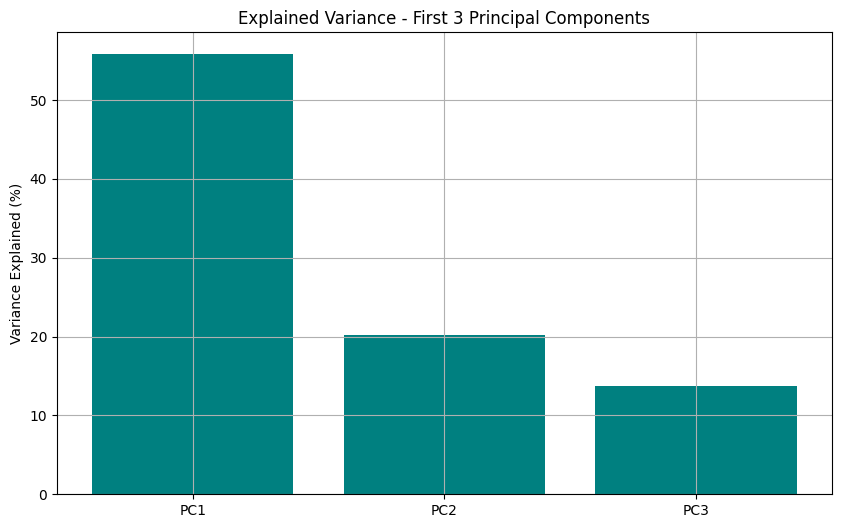

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.bar(['PC1', 'PC2', 'PC3'], pca.explained_variance_ratio_ * 100, color='teal')
plt.ylabel('Variance Explained (%)')
plt.title('Explained Variance - First 3 Principal Components')
plt.grid(True)
plt.show()

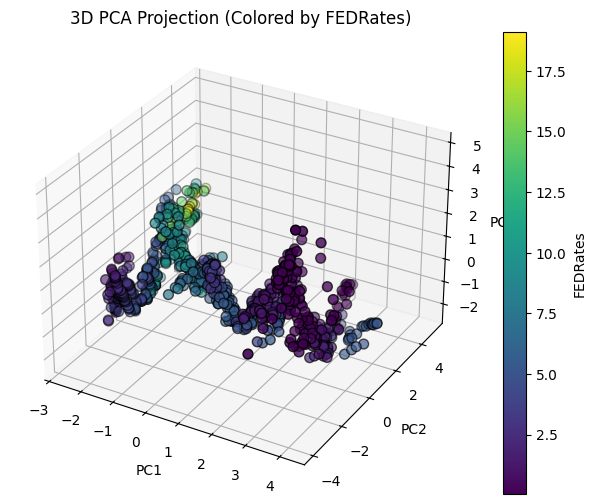

In [14]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df_pca[:,0], df_pca[:,1], df_pca[:,2], c=y, cmap='viridis', edgecolor='k', s=50)
ax.set_title('3D PCA Projection (Colored by FEDRates)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.colorbar(scatter, label='FEDRates')
plt.show()

In [21]:
# df_pca_final.to_csv('cleaned_for_clustering.csv', index=False)

In [22]:
# Load normalized data
df = pd.read_csv('Cleaned/cleaned_for_clustering.csv')

# Optional: Load FEDRates for comparison if needed
original_df = pd.read_csv('Cleaned/finaldataset.csv')
true_labels = original_df['FEDRates']

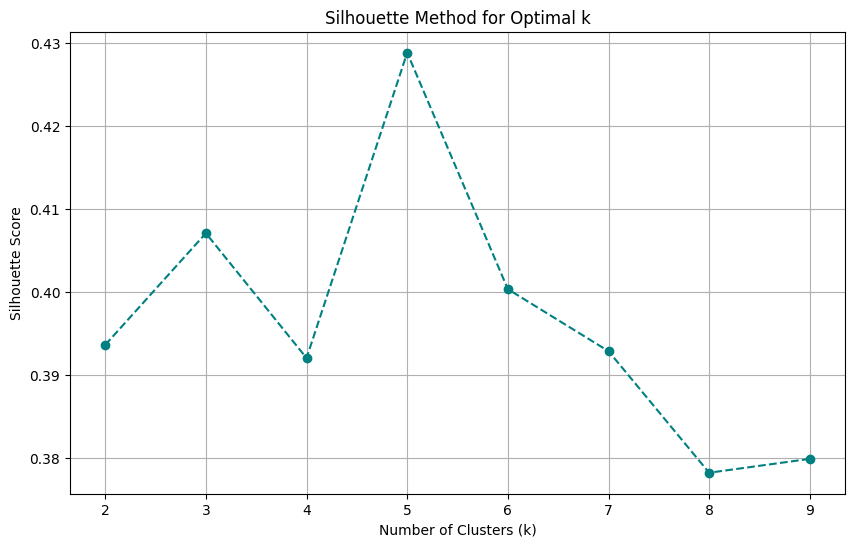

In [23]:
silhouette_scores = {}
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df)
    silhouette = silhouette_score(df, labels)
    silhouette_scores[k] = silhouette

# Plot silhouette scores for different k
plt.figure(figsize=(10, 6))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), marker='o', linestyle='--', color='teal')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True)
plt.show()

In [24]:
best_k_values = sorted(silhouette_scores, key=silhouette_scores.get, reverse=True)[:3]
print(f"Top 3 k values based on silhouette score: {best_k_values}")

Top 3 k values based on silhouette score: [5, 3, 6]


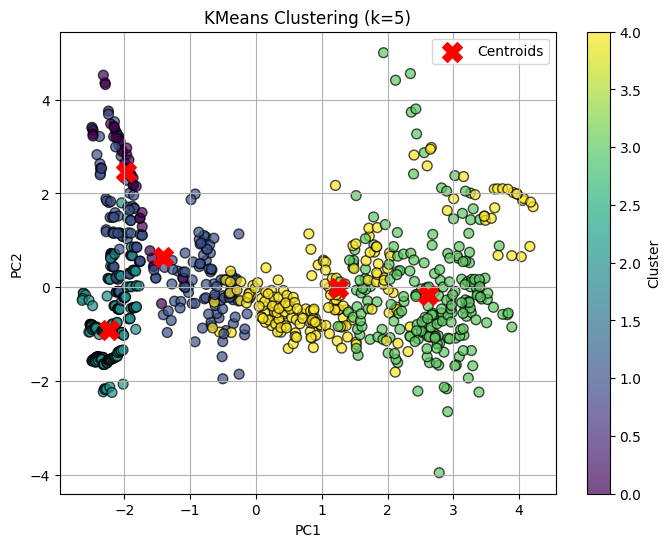

Silhouette Score for k=5: 0.43


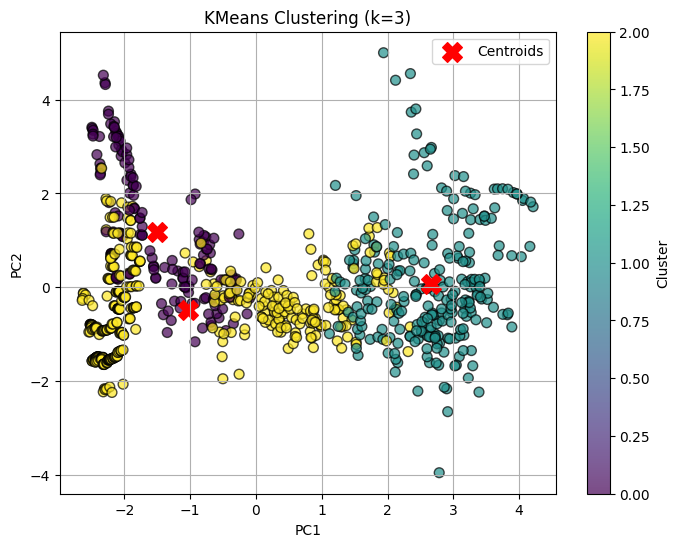

Silhouette Score for k=3: 0.41


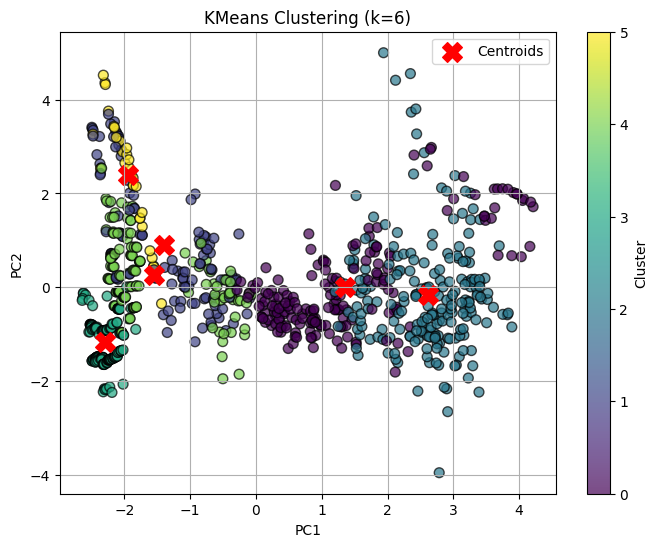

Silhouette Score for k=6: 0.40


In [25]:
for k in best_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(df)
    centroids = kmeans.cluster_centers_

    plt.figure(figsize=(8,6))
    scatter = plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
    plt.title(f'KMeans Clustering (k={k})')
    plt.xlabel(df.columns[0])
    plt.ylabel(df.columns[1])
    plt.legend()
    plt.colorbar(scatter, label='Cluster')
    plt.grid(True)
    plt.show()

    print(f'Silhouette Score for k={k}: {silhouette_score(df, cluster_labels):.2f}')

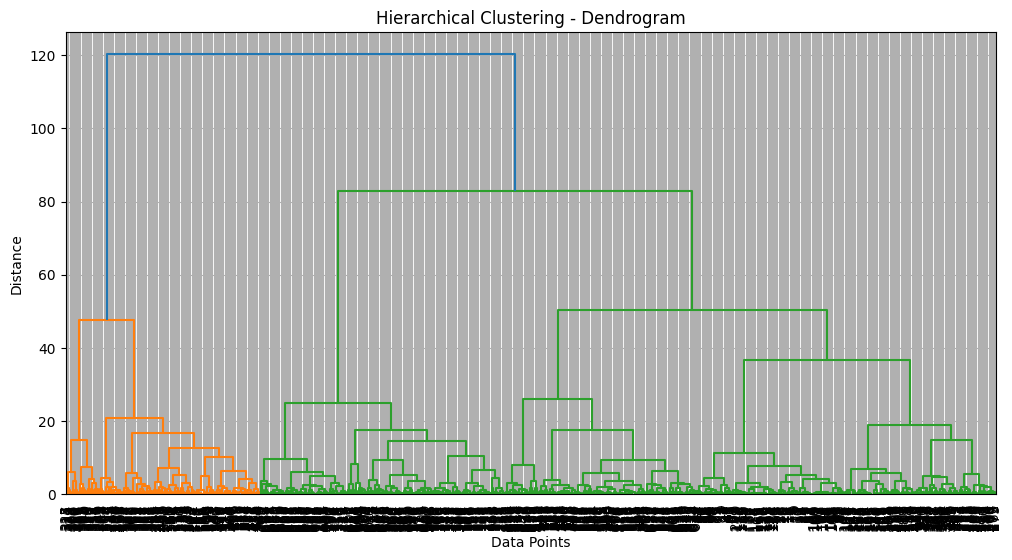

In [26]:
# Perform hierarchical clustering (ward linkage for variance minimization)
linkage_matrix = linkage(df, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering - Dendrogram')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

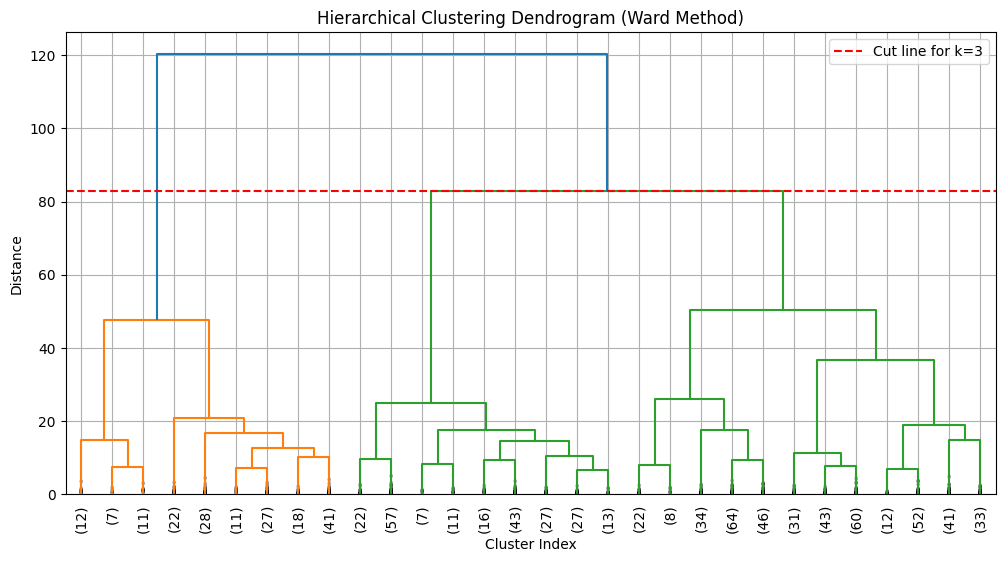

In [41]:
df_scaled = pd.read_csv('Cleaned/cleaned_for_clustering.csv')

# Perform Hierarchical Clustering (Ward's method)
Z = linkage(df_scaled, method='ward')

# Plot Dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Method)')
plt.xlabel('Cluster Index')
plt.ylabel('Distance')
plt.axhline(y=Z[-(3-1), 2], color='r', linestyle='--', label='Cut line for k=3')  # This line cuts at 3 clusters
plt.legend()
plt.grid(True)
plt.show()


cluster_labels = fcluster(Z, 3, criterion='maxclust')
df_scaled['Cluster'] = cluster_labels
df_scaled.to_csv('hierarchical_clusters_k3.csv', index=False)

In [34]:
#Cut dendrogram at certain level to get cluster labels
n_clusters = 3  # Choose based on visual cut-off from dendrogram
hc = AgglomerativeClustering(n_clusters=n_clusters)
hc_labels = hc.fit_predict(df)

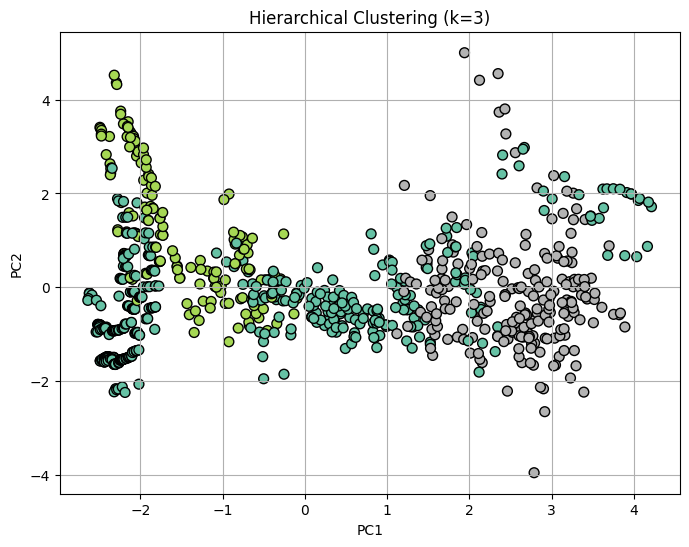

In [38]:
# Plot clustered data (first 2 features for visualization)
plt.figure(figsize=(8,6))
plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=hc_labels, cmap='Set2', edgecolor='k', s=50)
plt.title(f'Hierarchical Clustering (k={n_clusters})')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.grid(True)
plt.show()

In [29]:
from sklearn.neighbors import NearestNeighbors

neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(df)
distances, indices = nbrs.kneighbors(df)
distances = np.sort(distances[:, -1])

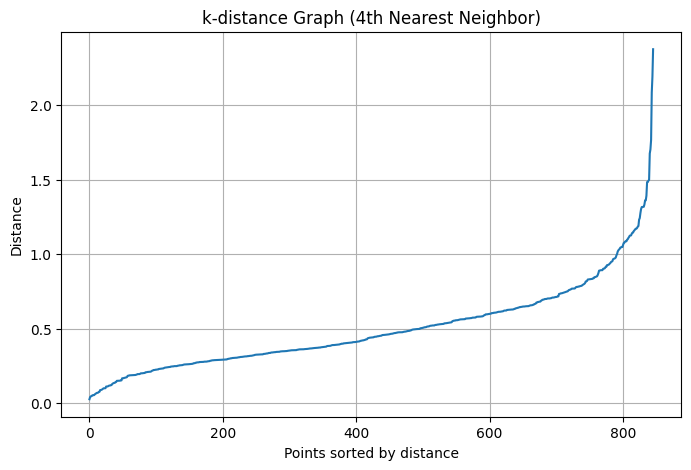

In [30]:
plt.figure(figsize=(8,5))
plt.plot(distances)
plt.title('k-distance Graph (4th Nearest Neighbor)')
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

In [31]:
# Based on this elbow plot, manually set eps (e.g., 0.5 is common if no clear elbow)
eps = 0.8
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(df)

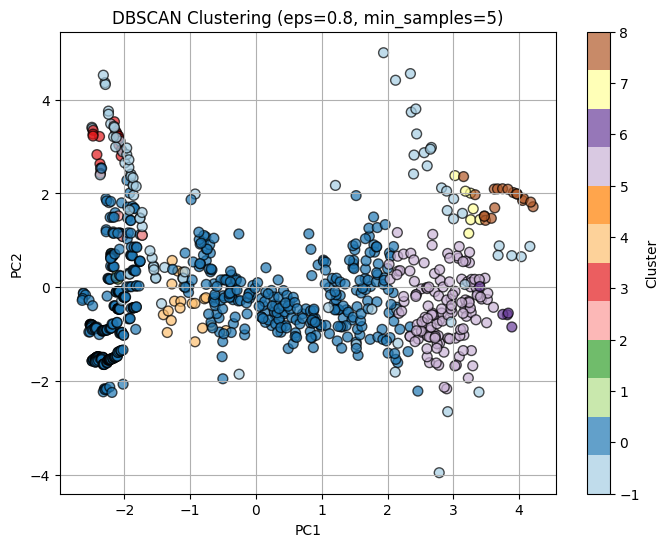

In [32]:
# Plot DBSCAN results
plt.figure(figsize=(8,6))
scatter = plt.scatter(df.iloc[:, 0], df.iloc[:, 1], c=dbscan_labels, cmap='Paired', edgecolor='k', s=50, alpha=0.7)
plt.title(f'DBSCAN Clustering (eps={eps}, min_samples={min_samples})')
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

In [33]:
# Count number of clusters detected (excluding noise points -1)
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f"DBSCAN detected {n_clusters_dbscan} clusters and {n_noise} noise points.")

DBSCAN detected 9 clusters and 90 noise points.
